In [13]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch import nn
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from torchdiffeq import odeint

In [15]:
from torch.utils.data import DataLoader

In [47]:
# CHANG THIS !!!!!
ckpt_path = "logs/David_cellstates-pseudotime_scaled_multiBnch/pde_singlebranch_twotimepoints/lightning_logs/version_4/checkpoints/epoch=997-total_loss=3.53358531.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [54]:
PINN.models._pde_informed_params.pde_singlebranch_twotimepoints

PINN.models._pde_informed_params.pde_singlebranch_twotimepoints

In [48]:
pde_model = model_class.load_from_checkpoint(ckpt_path)

In [49]:
device = 'cuda:1'
pde_model = pde_model.to(device)

In [19]:
torch.rand(11)*0.2

tensor([0.1095, 0.1498, 0.1644, 0.0503, 0.0147, 0.0303, 0.1178, 0.1054, 0.1610,
        0.0225, 0.0731])

In [20]:
next(pde_model.g.parameters())

Parameter containing:
tensor([ 0.0592,  0.2501,  0.1694, -0.0035,  0.1075, -0.0132,  0.1131,  0.1587,
         0.1250,  0.0953,  0.1213], device='cuda:1', requires_grad=True)

# load data

In [21]:
# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 8
n_grid = 300

In [22]:
train_DS = reader.SingleBranch_AnnDS(AnnData=adata, 
                                n_timepoint = n_timepoint,
                                timepoint_key = 'time',
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                log_transform=False,
                                norm_time = False)

def reduce_batchdim(batch):
    # for batch size 1 , remove the batch dimension
    if len(batch) == 1:
        batch = [ts.squeeze(0) for ts in batch[0]]
    return batch
batch_size = 1
train_DL = DataLoader(train_DS, batch_size=batch_size, num_workers=10, shuffle=True, collate_fn=reduce_batchdim)

In [25]:
u_b = torch.from_numpy(train_DS.u_b).clone().float().to(device)
s = torch.from_numpy(train_DS.s).clone().float().to(device)

# simulation

In [26]:
t_list = train_DS.t_b[:,0] / 5

In [27]:
t_list

array([0.2  , 0.216, 0.232, 0.248, 0.264, 0.28 , 0.296, 0.312])

In [50]:
t_list = train_DS.t_b[:,0] / 5

# loss 2 : dynamics 
# init_condition 
u_int_all = [u_b[0].detach().cpu().numpy()]

with torch.no_grad():
	for it in range(len(t_list)-1):
		t1 = t_list[it+1].item()
		t0 = t_list[it].item()

		step_size = np.around((t1 - t0)/15, decimals=1).item() 
		step_size = step_size if step_size > 0 else 0.05

		step_size = min(step_size, 0.4)

		ut0 = u_b[it,:]
		utp1 = u_b[it+1,:]

		# init condition : ut, s in a square, u in a square
		init_condition = (ut0, s)
		u_int, s_int = odeint(
						pde_model.ode_func,
						init_condition,
						torch.tensor([t0,t1]).type(torch.float32).to(device),
						atol=1e-8,
						rtol=1e-8,
						method='midpoint',
						options = {'step_size': step_size}
				)

		# boundary u of  the next timepoint
		u_int = nn.functional.relu(u_int)

		u_int_all.append(u_int[-1].cpu().numpy())

In [51]:
u_int_all = np.stack(u_int_all)

In [52]:
u_b.sum(axis=1), u_int_all.sum(axis=1)

(tensor([  0.9973,   1.6787,   5.2296,  14.3606,  59.5829, 136.5859, 325.4272,
         951.6102], device='cuda:1'),
 array([9.9732715e-01, 4.4318037e+03, 2.2708342e+03, 6.9908301e+03,
        1.7439223e+04, 3.9922912e+05, 1.8210898e+05, 5.1905981e+05],
       dtype=float32))

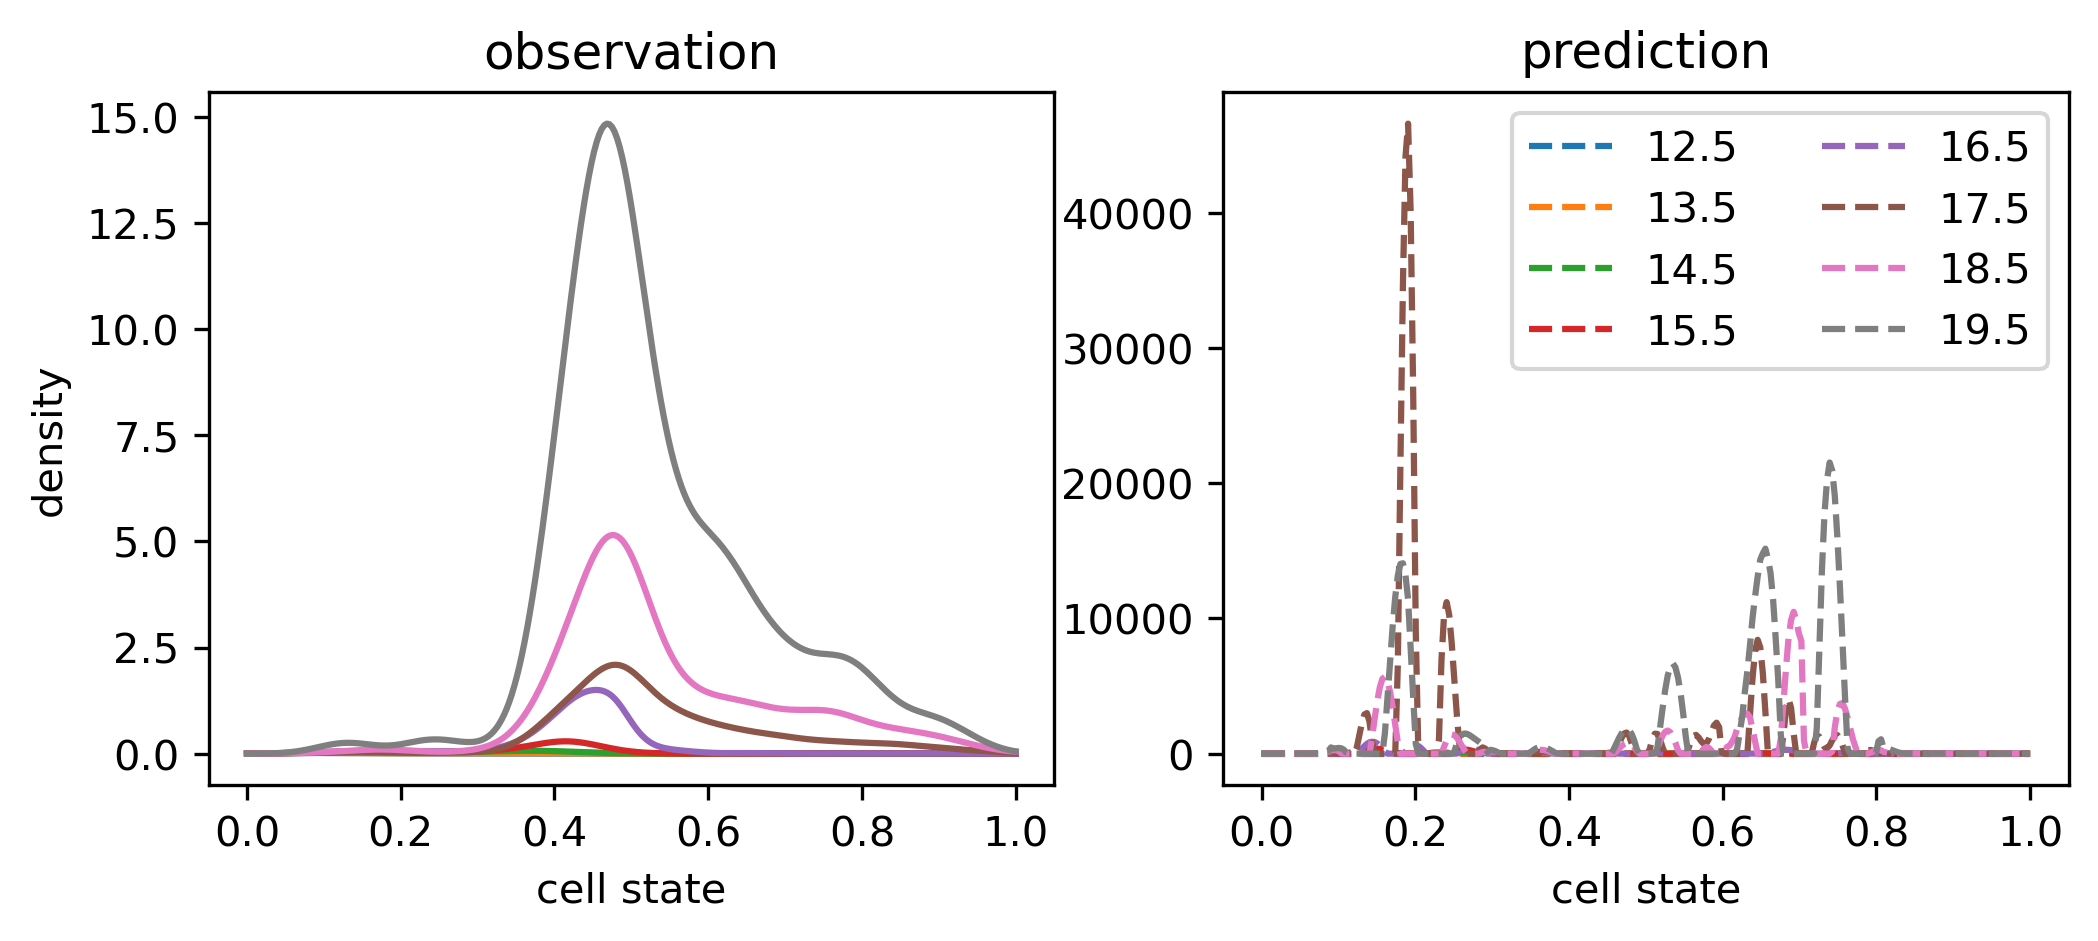

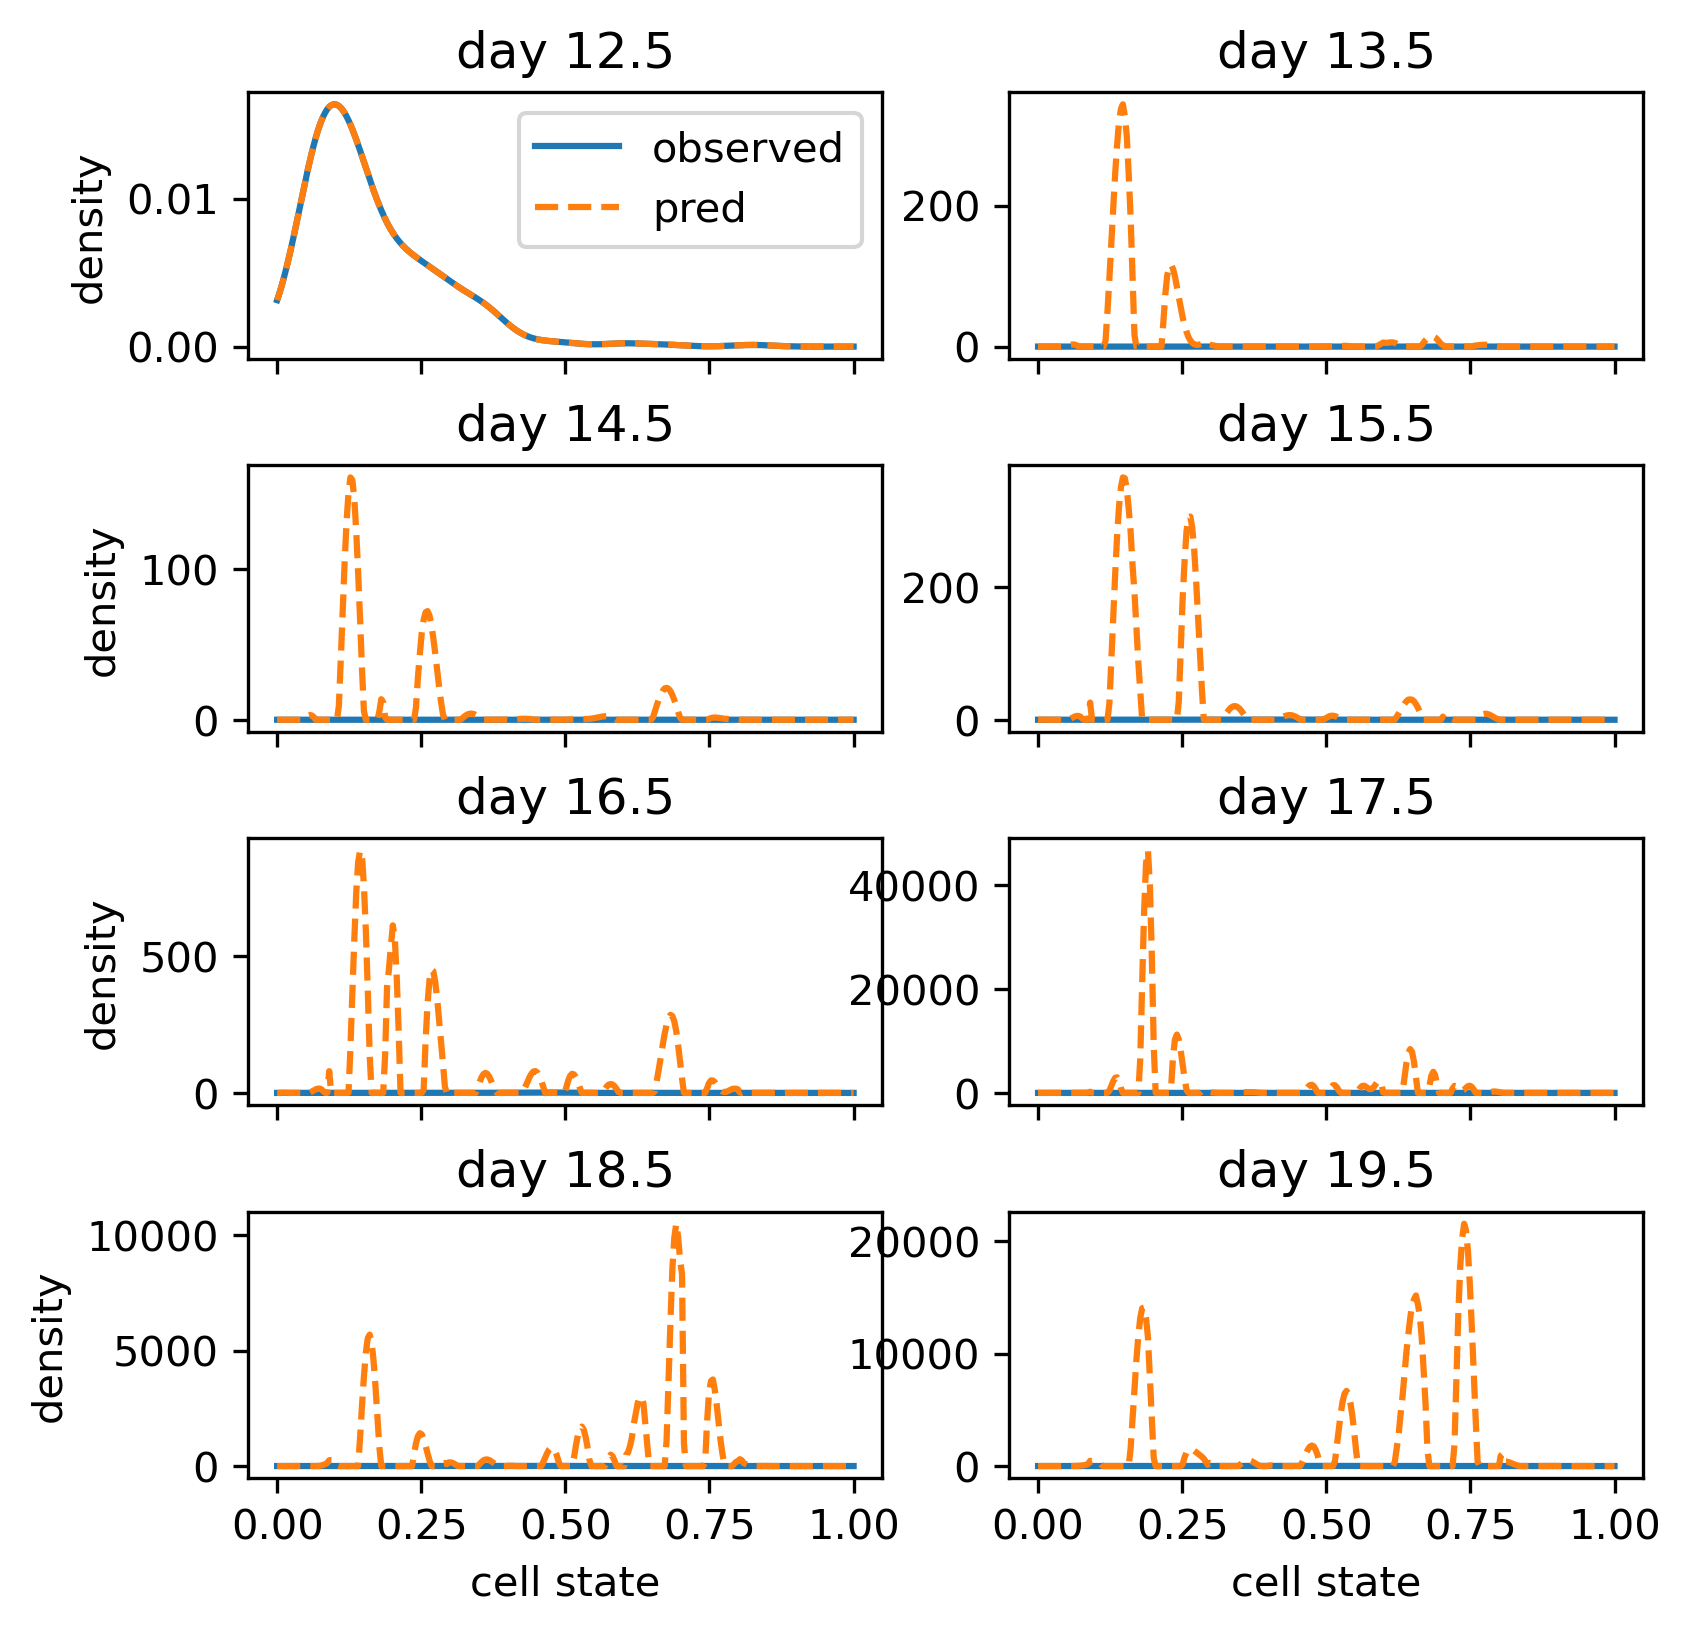

In [53]:
PINN.pl.density_by_time(u_b.detach().cpu().numpy(), u_int_all, train_DS.popD['t']);